# DIRECT MULTI-HORIZON FORECASTING

Цель: по одному causal-вектору $X_T$, известному не позже origin $T$, напрямую получить полный прогноз `[T+1, T+2, T+3, T+4, T+5]`. Каждый горизонт — следующая **официальная quote observation**, а не календарный день.

Для каждого corridor и каждого горизонта обучается отдельная модель целевого лог-изменения $\ln(P_{T+h}/P_T)$. Recursive future features не используются.

## 1. Environment и существующие артефакты

Notebook автоматически находит корень репозитория. Он повторно использует feature dataset, split Stage 2 и сохранённые прогнозы ARIMA Stage 4; ARIMA здесь не переобучается.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if not (ROOT / 'src').exists():
    raise RuntimeError(f'Не найден корень репозитория из {Path.cwd()}')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.direct_multihorizon import (
    HORIZONS, predict_next_5_rates, plot_representative_forecasts,
    run_direct_multihorizon,
)

artifact_paths = [
    ROOT / 'notebooks' / '01_fx_features_eda.ipynb',
    ROOT / 'notebooks' / '02_model_tournament.ipynb',
    ROOT / 'reports' / 'model_tournament_report.md',
    ROOT / 'reports' / 'arima_rate_multistep_results.csv',
    ROOT / 'reports' / 'arima_rate_test_forecasts.csv',
    ROOT / 'reports' / 'temporal_split_horizons.csv',
    ROOT / 'docs' / 'base_feature_dictionary.md',
    ROOT / 'docs' / 'cross_currency_methodology.md',
    ROOT / 'src' / 'normalization.py',
]
artifact_inventory = pd.DataFrame({
    'artifact': [p.relative_to(ROOT).as_posix() for p in artifact_paths],
    'exists': [p.exists() for p in artifact_paths],
})
display(artifact_inventory)
if not (ROOT / 'reports' / 'model_tournament_report.md').exists():
    display(Markdown('`reports/model_tournament_report.md` отсутствует в текущем snapshot; фактические Stage 1–4 результаты прочитаны из notebook и CSV-артефактов.'))

,artifact,exists
0,notebooks/01_fx_features_eda.ipynb,True
1,notebooks/02_model_tournament.ipynb,True
2,reports/model_tournament_report.md,False
3,reports/arima_rate_multistep_results.csv,True
4,reports/arima_rate_test_forecasts.csv,True
5,reports/temporal_split_horizons.csv,True
6,docs/base_feature_dictionary.md,True
7,docs/cross_currency_methodology.md,True
8,src/normalization.py,True


`reports/model_tournament_report.md` отсутствует в текущем snapshot; фактические Stage 1–4 результаты прочитаны из notebook и CSV-артефактов.

## 2. Запуск воспроизводимого pipeline

**TEST SET IS LOCKED.** Feature selection, scaler и гиперпараметры выбираются без test. Test используется только после фиксации всех corridor×horizon configurations.

In [2]:
run = run_direct_multihorizon(ROOT, make_plots=False)
print('Status:', run['status'])
print('Dataset:', run['dataset_path'].relative_to(ROOT))
print('SHA-256:', run['dataset_sha256'])
print('Final features:', len(run['features']))

Status: PASS
Dataset: data\features\fx_features_daily.parquet
SHA-256: 6737d1ebec82f66b04f431c79d79680a7d5d8b775e6a335c133ef3d49efcd131
Final features: 15


## 3. Dataset validation

Используется фактически найденный основной feature parquet. Сортировка — `corridor, date`; ключ должен быть уникален.

In [3]:
frame = run['frame']
dataset_summary = (frame.groupby('corridor').agg(
    first_date=('date', 'min'), last_date=('date', 'max'), rows=('date', 'size'),
    missing_rate=('rate', lambda x: int(x.isna().sum())),
).reset_index())
display(dataset_summary)
print('Shape:', frame.shape)
print('Duplicate corridor+date:', int(frame.duplicated(['corridor', 'date']).sum()))
print('Sorted:', frame.equals(frame.sort_values(['corridor', 'date'], kind='stable').reset_index(drop=True)))

,corridor,first_date,last_date,rows,missing_rate
0,AMD_RUB,2019-01-10,2026-09-03,1889,0
1,KGS_RUB,2019-01-10,2026-09-03,1889,0
2,KZT_RUB,2019-01-10,2026-09-03,1889,0
3,TJS_RUB,2019-01-10,2026-09-03,1889,0
4,UZS_RUB,2019-01-10,2026-09-03,1889,0


Shape: (9445, 120)
Duplicate corridor+date: 0
Sorted: True


## 4. Direct targets и right censoring

Для $h=1...5$: `actual_rate_h = rate.shift(-h)` и `target_log_return_h = ln(actual_rate_h / rate_T)` внутри каждого corridor. Последние пять origin не имеют полного future window: это right censoring, а не пропуски исходных данных. Targets никогда не входят в X.

In [4]:
target_columns = [f'target_log_return_h{h}' for h in HORIZONS]
actual_columns = [f'actual_rate_h{h}' for h in HORIZONS]
right_censoring = frame.groupby('corridor')['has_full_horizon_5'].agg(
    usable_origins='sum', total_rows='size'
).reset_index()
right_censoring['right_censored_origins'] = right_censoring.total_rows - right_censoring.usable_origins
display(right_censoring)
display(frame[['date', 'corridor', 'rate', *actual_columns, *target_columns, 'has_full_horizon_5']].head(3))

,corridor,usable_origins,total_rows,right_censored_origins
0,AMD_RUB,1884,1889,5
1,KGS_RUB,1884,1889,5
2,KZT_RUB,1884,1889,5
3,TJS_RUB,1884,1889,5
4,UZS_RUB,1884,1889,5


,date,corridor,rate,actual_rate_h1,actual_rate_h2,actual_rate_h3,actual_rate_h4,actual_rate_h5,target_log_return_h1,target_log_return_h2,target_log_return_h3,target_log_return_h4,target_log_return_h5,has_full_horizon_5
0,2019-01-10,AMD_RUB,0.138280,0.137743,0.137689,0.138113,0.137802,0.137370,-0.003891,-0.004283,-0.001208,-0.003463,-0.006603,True
1,2019-01-11,AMD_RUB,0.137743,0.137689,0.138113,0.137802,0.137370,0.136856,-0.000392,0.002683,0.000428,-0.002712,-0.006460,True
2,2019-01-12,AMD_RUB,0.137689,0.138113,0.137802,0.137370,0.136856,0.136737,0.003075,0.000820,-0.002320,-0.006068,-0.006938,True


## 5. Causal feature set и strict leakage audit

Ни одна колонка с `future`, `regret`, `good_day`, `safe`, `label` или `target` не допускается в X. Все 15 кандидатов существуют в dataset и описаны causal trailing/as-of формулами. При неясном causal status поле исключалось бы.

In [5]:
display(run['feature_audit'])
print('Used features:', run['features'])

,feature,available_at_t,reason,used,train_missing_share,train_variance,exact_duplicate_of,correlated_with,correlation
0,ret_1,True,causal trailing/as-of feature documented in re...,True,0.000756,0.000191,,,NaN
1,ret_3,True,causal trailing/as-of feature documented in re...,True,0.002269,0.000644,,,NaN
2,ret_5,True,causal trailing/as-of feature documented in re...,True,0.003782,0.001134,,,NaN
3,vol_5,True,causal trailing/as-of feature documented in re...,True,0.003782,0.000105,,,NaN
4,vol_20,True,causal trailing/as-of feature documented in re...,True,0.015129,0.000088,,,NaN
5,dist_min_20,True,causal trailing/as-of feature documented in re...,True,0.014372,0.002602,,,NaN
6,favourability_percentile_90,True,causal trailing/as-of feature documented in re...,True,0.068079,0.125108,,,NaN
7,dist_sma_20,True,causal trailing/as-of feature documented in re...,True,0.014372,0.001494,,,NaN
8,broad_rub_return_1,True,causal trailing/as-of feature documented in re...,True,0.000756,0.000162,,,NaN
9,broad_rub_return_3,True,causal trailing/as-of feature documented in re...,True,0.002269,0.000620,,,NaN


Used features: ['ret_1', 'ret_3', 'ret_5', 'vol_5', 'vol_20', 'dist_min_20', 'favourability_percentile_90', 'dist_sma_20', 'broad_rub_return_1', 'broad_rub_return_3', 'broad_rub_return_5', 'corridor_specific_return_1', 'return_sign_reversal_up', 'reversal_strength', 'near_min_reversal_010']


## 6. Feature redundancy

Exact duplicates, near-zero variance, missingness и Pearson correlation проверяются только на TRAIN. При `abs(corr) >= 0.95` сохраняется первый, более простой признак. PCA и VIF по широкому набору не используются.

In [6]:
corr = run['correlations'].abs()
high_pairs = []
for i, left in enumerate(corr.columns):
    for right in corr.columns[i + 1:]:
        if corr.loc[left, right] >= 0.95:
            high_pairs.append({'left': left, 'right': right, 'abs_train_corr': corr.loc[left, right]})
display(pd.DataFrame(high_pairs))
print('Финальное число признаков:', len(run['features']))

""


Финальное число признаков: 15


## 7. Temporal split, purge и preprocessing

Повторно используются границы Stage 2 и те же validation/test forecast origins, рассчитанные с запасом до T+10. Для supervised labels train-origin допустим только когда его T+5 остаётся в TRAIN; validation-origin не может использовать label из TEST. Это обеспечивает purge не менее пяти quote observations. Missing warm-up rows удаляются complete-case способом; backward fill запрещён.

In [7]:
display(run['splits'])
display(run['partition_audit'])
display(Markdown('Ridge использует `StandardScaler` внутри pipeline: при tuning fit только на TRAIN; после выбора alpha — refit на допустимых TRAIN+VALIDATION rows. Gradient Boosting scaling не требует.'))

,corridor,train_start,train_end,validation_start,validation_end,test_start,test_end,n_train,n_validation,n_test,validation_origin_start,validation_origin_end,test_origin_start,test_origin_end,n_validation_origins,n_test_origins,n_right_censored_origins,forecast_horizons,primary_horizon,max_horizon
0,AMD_RUB,2019-01-10,2024-05-23,2024-05-24,2025-07-12,2025-07-15,2026-09-03,1322,283,284,2024-05-23,2025-06-28,2025-07-12,2026-08-20,274,275,10,"1,3,5,10",5,10
1,KGS_RUB,2019-01-10,2024-05-23,2024-05-24,2025-07-12,2025-07-15,2026-09-03,1322,283,284,2024-05-23,2025-06-28,2025-07-12,2026-08-20,274,275,10,"1,3,5,10",5,10
2,KZT_RUB,2019-01-10,2024-05-23,2024-05-24,2025-07-12,2025-07-15,2026-09-03,1322,283,284,2024-05-23,2025-06-28,2025-07-12,2026-08-20,274,275,10,"1,3,5,10",5,10
3,TJS_RUB,2019-01-10,2024-05-23,2024-05-24,2025-07-12,2025-07-15,2026-09-03,1322,283,284,2024-05-23,2025-06-28,2025-07-12,2026-08-20,274,275,10,"1,3,5,10",5,10
4,UZS_RUB,2019-01-10,2024-05-23,2024-05-24,2025-07-12,2025-07-15,2026-09-03,1322,283,284,2024-05-23,2025-06-28,2025-07-12,2026-08-20,274,275,10,"1,3,5,10",5,10


,corridor,partition,rows_before_complete_case,rows_after_complete_case,rows_lost,start,end,train_validation_purge_observations,validation_test_purge_observations
0,AMD_RUB,train,1317,1227,90,2019-05-24,2024-05-16,5,10
1,AMD_RUB,validation,274,274,0,2024-05-23,2025-06-28,5,10
2,AMD_RUB,refit,1600,1510,90,2019-05-24,2025-07-05,5,10
3,AMD_RUB,test,275,275,0,2025-07-12,2026-08-20,5,10
4,KGS_RUB,train,1317,1227,90,2019-05-24,2024-05-16,5,10
5,KGS_RUB,validation,274,274,0,2024-05-23,2025-06-28,5,10
6,KGS_RUB,refit,1600,1510,90,2019-05-24,2025-07-05,5,10
7,KGS_RUB,test,275,275,0,2025-07-12,2026-08-20,5,10
8,KZT_RUB,train,1317,1227,90,2019-05-24,2024-05-16,5,10
9,KZT_RUB,validation,274,274,0,2024-05-23,2025-06-28,5,10


Ridge использует `StandardScaler` внутри pipeline: при tuning fit только на TRAIN; после выбора alpha — refit на допустимых TRAIN+VALIDATION rows. Gradient Boosting scaling не требует.

## 8. Models и validation-only selection

Для каждого `corridor × h` отдельно выбираются Ridge (`alpha=[0.1,1,10,100]`) и GradientBoostingRegressor (`n_estimators=[100,200]`, `max_depth=[2,3]`, `learning_rate=[0.03,0.05]`). Primary selection metric — validation MAE после восстановления rate; RMSE — tie-break.

In [8]:
print('Validation candidates:', len(run['validation_candidates']))
display(run['selections'][['corridor', 'horizon', 'model', 'params', 'MAE', 'RMSE', 'DA']])

Validation candidates: 300


,corridor,horizon,model,params,MAE,RMSE,DA
0,AMD_RUB,1,DIRECT_GRADIENT_BOOSTING,"{""learning_rate"": 0.05, ""max_depth"": 2, ""n_est...",0.001674,0.002449,0.562044
1,AMD_RUB,1,DIRECT_RIDGE,"{""alpha"": 0.1}",0.001672,0.002445,0.562044
2,AMD_RUB,2,DIRECT_GRADIENT_BOOSTING,"{""learning_rate"": 0.03, ""max_depth"": 3, ""n_est...",0.002734,0.003909,0.489051
3,AMD_RUB,2,DIRECT_RIDGE,"{""alpha"": 1.0}",0.002703,0.003876,0.580292
4,AMD_RUB,3,DIRECT_GRADIENT_BOOSTING,"{""learning_rate"": 0.03, ""max_depth"": 2, ""n_est...",0.003422,0.004862,0.459854
5,AMD_RUB,3,DIRECT_RIDGE,"{""alpha"": 100.0}",0.003423,0.004886,0.514599
6,AMD_RUB,4,DIRECT_GRADIENT_BOOSTING,"{""learning_rate"": 0.03, ""max_depth"": 2, ""n_est...",0.003873,0.005531,0.489051
7,AMD_RUB,4,DIRECT_RIDGE,"{""alpha"": 100.0}",0.003930,0.005615,0.518248
8,AMD_RUB,5,DIRECT_GRADIENT_BOOSTING,"{""learning_rate"": 0.03, ""max_depth"": 2, ""n_est...",0.004279,0.006168,0.481752
9,AMD_RUB,5,DIRECT_RIDGE,"{""alpha"": 100.0}",0.004302,0.006274,0.525547


## 9. Unified forecast vector API

Все пять horizon models получают один и тот же $X_T$. Ни прогноз другой модели, ни фактические признаки T+1...T+5 не используются.

In [9]:
example_corridor = sorted(run['models'])[0]
example_row = run['frame'].loc[
    (run['frame'].corridor == example_corridor) &
    (run['frame'].date == run['splits'].set_index('corridor').loc[example_corridor, 'test_origin_start'])
].iloc[0]
forecast_vector = predict_next_5_rates(
    example_row, example_corridor, 'DIRECT_RIDGE', run['models'], run['features']
)
print(example_corridor, example_row.date.date())
print('Forecast vector [T+1,...,T+5]:', forecast_vector)

AMD_RUB 2025-07-12
Forecast vector [T+1,...,T+5]: [0.2027874792869316, 0.20268567115472994, 0.20292196069121077, 0.2029697432280895, 0.20306103874597442]


## 10. Locked-test predictions и metrics

Naive использует $\hat P_{T+h}=P_T$ на тех же rows. Сохранённая ARIMA агрегируется на том же intersection origins. Endpoint MAE/RMSE/DA считаются отдельно для H1...H5; дополнительно считаются Path MAE, Future-Best MAE и Regret MAE.

In [10]:
prediction_columns = ['corridor', 'date', 'model', 'rate_t', *actual_columns, *[f'predicted_rate_h{h}' for h in HORIZONS], 'actual_future_best_5', 'predicted_future_best_5', 'actual_regret_5', 'predicted_regret_5']
display(run['predictions'][prediction_columns].head())
display(run['results'])

,corridor,date,model,rate_t,actual_rate_h1,actual_rate_h2,actual_rate_h3,actual_rate_h4,actual_rate_h5,predicted_rate_h1,predicted_rate_h2,predicted_rate_h3,predicted_rate_h4,predicted_rate_h5,actual_future_best_5,predicted_future_best_5,actual_regret_5,predicted_regret_5
0,AMD_RUB,2025-07-12,DIRECT_RIDGE,0.202874,0.204020,0.202953,0.203038,0.203545,0.203818,0.202787,0.202686,0.202922,0.202970,0.203061,0.202953,0.202686,0.00000,0.000928
1,AMD_RUB,2025-07-12,DIRECT_GRADIENT_BOOSTING,0.202874,0.204020,0.202953,0.203038,0.203545,0.203818,0.202932,0.202869,0.202956,0.203030,0.203294,0.202953,0.202869,0.00000,0.000025
2,AMD_RUB,2025-07-15,DIRECT_RIDGE,0.204020,0.202953,0.203038,0.203545,0.203818,0.204068,0.204050,0.203915,0.204066,0.204161,0.204356,0.202953,0.203915,0.00523,0.000514
3,AMD_RUB,2025-07-15,DIRECT_GRADIENT_BOOSTING,0.204020,0.202953,0.203038,0.203545,0.203818,0.204068,0.204214,0.204314,0.204219,0.204397,0.204592,0.202953,0.204214,0.00523,0.000000
4,AMD_RUB,2025-07-16,DIRECT_RIDGE,0.202953,0.203038,0.203545,0.203818,0.204068,0.203371,0.202747,0.202884,0.203178,0.203303,0.203402,0.203038,0.202747,0.00000,0.001015


,corridor,model,MAE_H1,RMSE_H1,DA_H1,MAE_H2,RMSE_H2,DA_H2,MAE_H3,RMSE_H3,...,DA_H4,MAE_H5,RMSE_H5,DA_H5,Path_MAE_5,Future_Best_MAE_5,Regret_MAE_5,n_forecasts,MAE_ratio_vs_naive_H5,beats_naive_H5
0,AMD_RUB,ARIMA_RATE,0.001335,0.001765,0.000000,0.002044,0.002687,0.000000,0.002689,0.003413,...,0.000000,0.003491,0.004413,0.000000,0.002538,0.002492,0.010045,275,1.000000,False
1,AMD_RUB,DIRECT_GRADIENT_BOOSTING,0.001311,0.001743,0.574545,0.001992,0.002637,0.589091,0.002652,0.003384,...,0.581818,0.003436,0.004344,0.556364,0.002494,0.002464,0.009775,275,0.984088,True
2,AMD_RUB,DIRECT_RIDGE,0.001327,0.001756,0.552727,0.002003,0.002678,0.578182,0.002640,0.003386,...,0.574545,0.003462,0.004387,0.567273,0.002502,0.002467,0.009627,275,0.991767,True
3,AMD_RUB,NAIVE,0.001335,0.001765,0.000000,0.002044,0.002687,0.000000,0.002689,0.003413,...,0.000000,0.003491,0.004413,0.000000,0.002538,0.002492,0.010045,275,1.000000,False
4,KGS_RUB,ARIMA_RATE,0.005722,0.007620,0.000000,0.008860,0.011634,0.000000,0.011664,0.014826,...,0.000000,0.015246,0.019270,0.000000,0.011020,0.011122,0.010534,275,1.000000,False
5,KGS_RUB,DIRECT_GRADIENT_BOOSTING,0.005664,0.007536,0.552727,0.008592,0.011371,0.618182,0.011602,0.014739,...,0.592727,0.015070,0.018989,0.560000,0.010878,0.010829,0.010123,275,0.988419,True
6,KGS_RUB,DIRECT_RIDGE,0.005779,0.007546,0.516364,0.008855,0.011588,0.520000,0.011646,0.014827,...,0.556364,0.015228,0.019424,0.563636,0.011012,0.010578,0.009805,275,0.998804,True
7,KGS_RUB,NAIVE,0.005722,0.007620,0.000000,0.008860,0.011634,0.000000,0.011664,0.014826,...,0.000000,0.015246,0.019270,0.000000,0.011020,0.011122,0.010534,275,1.000000,False
8,KZT_RUB,ARIMA_RATE,0.001242,0.001659,0.541818,0.001909,0.002444,0.461818,0.002291,0.002979,...,0.538182,0.002882,0.003886,0.523636,0.002190,0.002113,0.011017,275,0.993455,True
9,KZT_RUB,DIRECT_GRADIENT_BOOSTING,0.001229,0.001626,0.581818,0.001853,0.002383,0.592727,0.002273,0.002914,...,0.563636,0.002909,0.003865,0.530909,0.002176,0.002066,0.010945,275,1.002467,False


Directional Accuracy: совпадающие знаки считаются верными, включая `actual=0` и `predicted=0`. Если predicted change равен нулю, а actual change не равен нулю, прогноз направления неверен. Lower RUB-per-recipient-currency выгоднее отправителю RUB.

## 11. Winners по разным продуктовым метрикам

Лучшие модели по endpoint H5, полной path, future-best и regret могут различаться. Это финальное test-описание, а не повторный подбор гиперпараметров.

In [11]:
display(run['winners'])
best_direct = (run['results'][run['results'].model.str.startswith('DIRECT')]
               .sort_values(['corridor', 'MAE_H5']).groupby('corridor').first().reset_index())
print('Best direct family beats Naive at H5:', int(best_direct.beats_naive_H5.sum()), '/', len(best_direct), 'corridors')

,corridor,best_endpoint_model_h5,best_path_model,best_future_best_model,best_regret_model
0,AMD_RUB,DIRECT_GRADIENT_BOOSTING,DIRECT_GRADIENT_BOOSTING,DIRECT_GRADIENT_BOOSTING,DIRECT_RIDGE
1,KGS_RUB,DIRECT_GRADIENT_BOOSTING,DIRECT_GRADIENT_BOOSTING,DIRECT_RIDGE,DIRECT_RIDGE
2,KZT_RUB,ARIMA_RATE,DIRECT_GRADIENT_BOOSTING,DIRECT_GRADIENT_BOOSTING,DIRECT_GRADIENT_BOOSTING
3,TJS_RUB,DIRECT_RIDGE,DIRECT_RIDGE,DIRECT_RIDGE,DIRECT_RIDGE
4,UZS_RUB,DIRECT_GRADIENT_BOOSTING,DIRECT_GRADIENT_BOOSTING,DIRECT_GRADIENT_BOOSTING,DIRECT_RIDGE


Best direct family beats Naive at H5: 4 / 5 corridors


## 12. Feature importance

Для Ridge показаны абсолютные standardized coefficients, для Gradient Boosting — встроенные `feature_importances_`, усреднённые по пяти horizon models. Это predictive association, не causal effect.

In [12]:
display(run['importance'].loc[run['importance']['rank'] <= 5])

,corridor,model,feature,importance,rank
19,AMD_RUB,DIRECT_GRADIENT_BOOSTING,vol_20,0.288108,1
28,AMD_RUB,DIRECT_GRADIENT_BOOSTING,reversal_strength,0.275043,2
18,AMD_RUB,DIRECT_GRADIENT_BOOSTING,vol_5,0.078819,3
20,AMD_RUB,DIRECT_GRADIENT_BOOSTING,dist_min_20,0.049511,4
24,AMD_RUB,DIRECT_GRADIENT_BOOSTING,broad_rub_return_3,0.048060,5
3,AMD_RUB,DIRECT_RIDGE,vol_5,0.005567,1
4,AMD_RUB,DIRECT_RIDGE,vol_20,0.005483,2
10,AMD_RUB,DIRECT_RIDGE,broad_rub_return_5,0.005197,3
2,AMD_RUB,DIRECT_RIDGE,ret_5,0.003392,4
9,AMD_RUB,DIRECT_RIDGE,broad_rub_return_3,0.003317,5


## 13. Representative forecast paths

Три origin на коридор показаны внутри одного графика. История заканчивается в T; справа сравниваются actual, direct Ridge и Naive path. Визуальные примеры не используются для выбора модели.

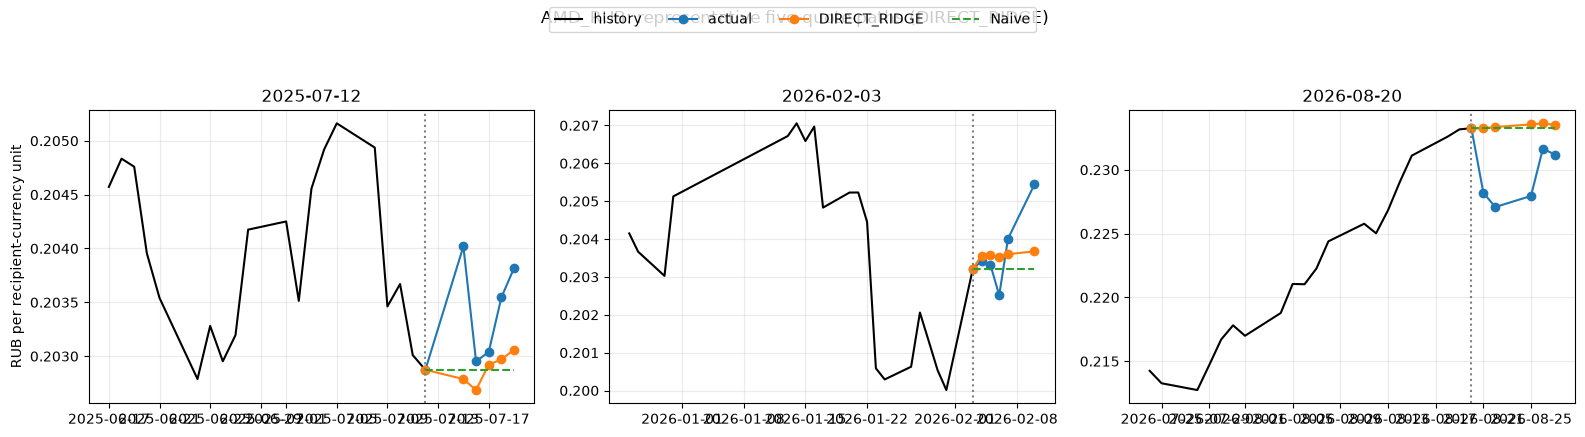

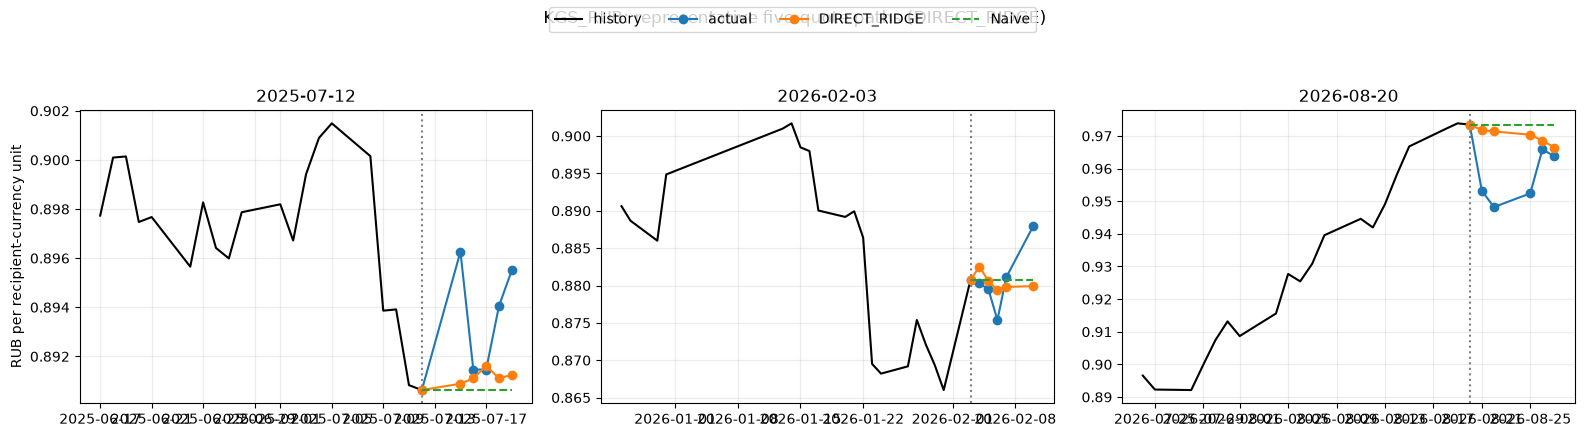

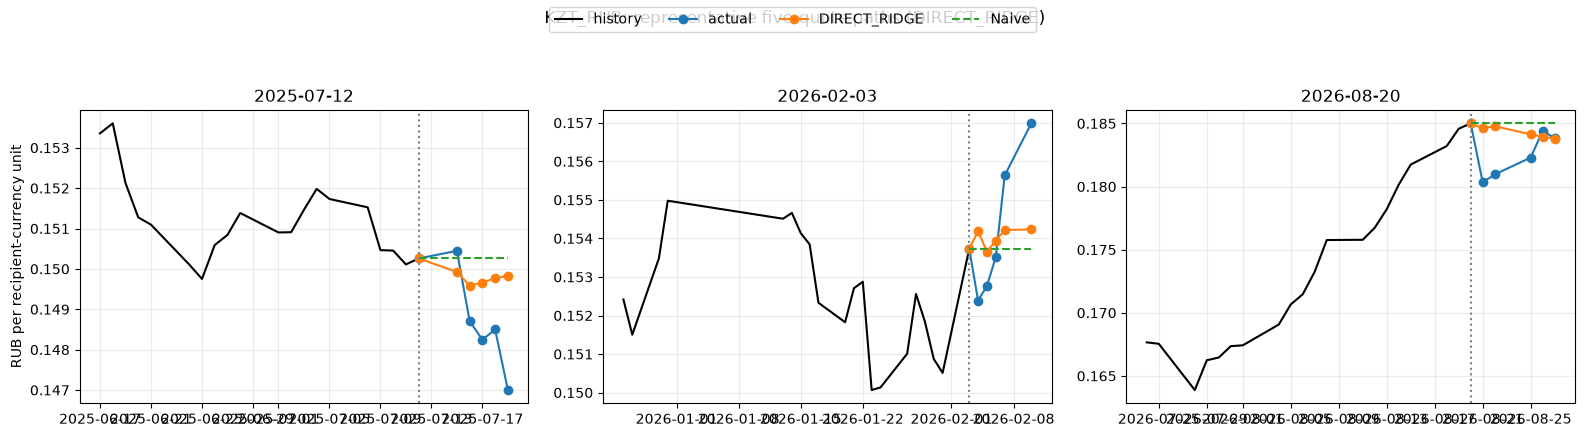

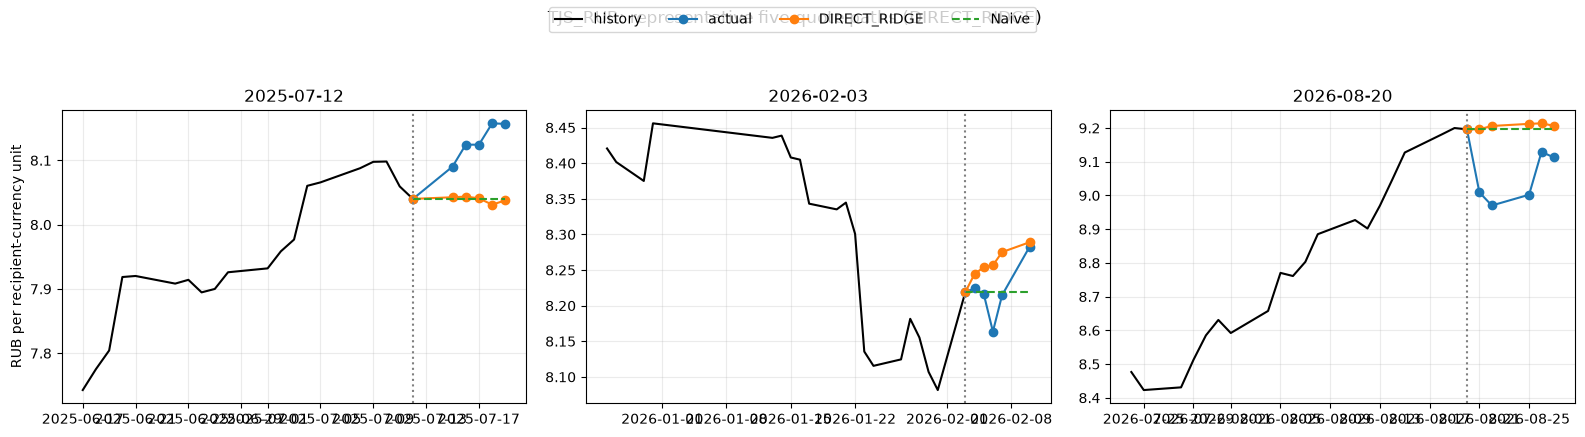

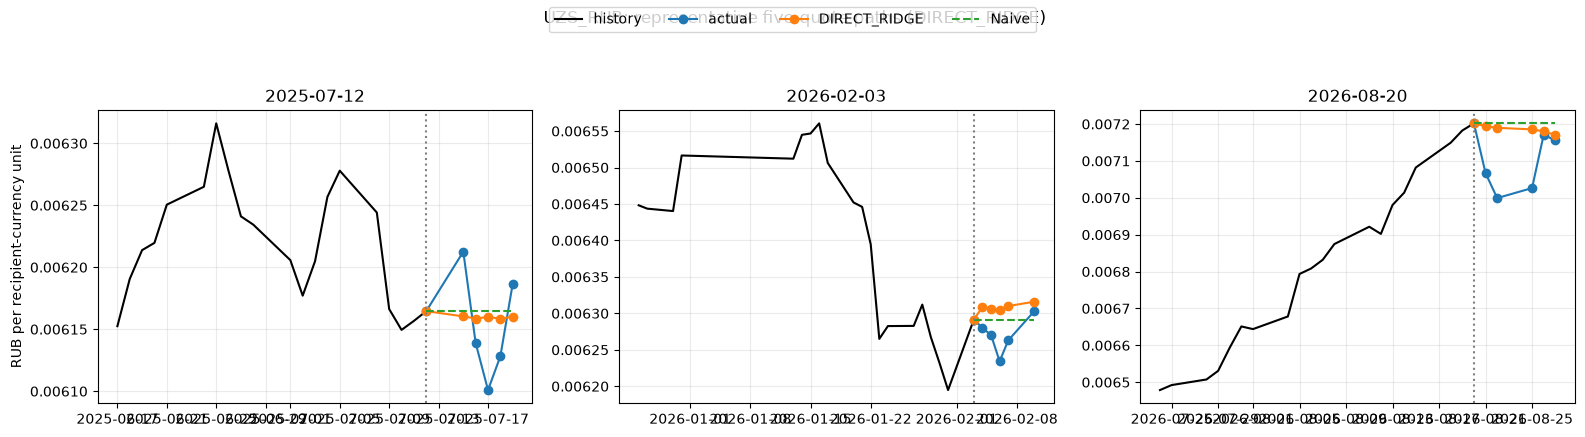

In [13]:
direct_only = run['predictions'][run['predictions'].model.str.startswith('DIRECT')].copy()
plot_representative_forecasts(run['frame'], direct_only, model='DIRECT_RIDGE')

## 14. Final leakage check

In [14]:
display(run['leakage'])
leakage_status = 'PASS' if run['leakage'].passed.all() else 'FAIL'
print('DIRECT MULTIHORIZON LEAKAGE CHECK:', leakage_status)

,check,passed
0,all X known at T,True
1,no actual T+1...T+5 used as features,True
2,no future exogenous variables used,True
3,no shift(-N) features in X,True
4,no future/regret/good_day/safe labels in X,True
5,scaler fit train only,True
6,temporal split only,True
7,purge >= 5,True
8,hyperparameters selected on validation only,True
9,test used once,True


DIRECT MULTIHORIZON LEAKAGE CHECK: PASS


## 15. Final output

In [15]:
best_direct = (run['results'][run['results'].model.str.startswith('DIRECT')]
               .sort_values(['corridor', 'MAE_H5']).groupby('corridor').first().reset_index())
print('DIRECT MULTIHORIZON FORECASTING:', run['status'])
print('Forecast vector: [T+1, T+2, T+3, T+4, T+5]')
print('\nBest direct model by corridor (H5):')
print(best_direct[['corridor', 'model', 'MAE_H5', 'MAE_ratio_vs_naive_H5']].to_string(index=False))
print(f'\nBeats Naive at H5: {int(best_direct.beats_naive_H5.sum())}/{len(best_direct)} corridors')
print('\nWinners by product metric:')
print(run['winners'].to_string(index=False))
print('\nLeakage check:', leakage_status)
print('\nFiles:')
print('notebooks/03_direct_multihorizon_forecasting.ipynb')
for key in ('predictions', 'results', 'report'):
    print(run['outputs'][key].relative_to(ROOT).as_posix())

DIRECT MULTIHORIZON FORECASTING: PASS
Forecast vector: [T+1, T+2, T+3, T+4, T+5]

Best direct model by corridor (H5):
corridor                    model   MAE_H5  MAE_ratio_vs_naive_H5
 AMD_RUB DIRECT_GRADIENT_BOOSTING 0.003436               0.984088
 KGS_RUB DIRECT_GRADIENT_BOOSTING 0.015070               0.988419
 KZT_RUB DIRECT_GRADIENT_BOOSTING 0.002909               1.002467
 TJS_RUB             DIRECT_RIDGE 0.140707               0.964377
 UZS_RUB DIRECT_GRADIENT_BOOSTING 0.000118               0.994159

Beats Naive at H5: 4/5 corridors

Winners by product metric:
corridor   best_endpoint_model_h5          best_path_model   best_future_best_model        best_regret_model
 AMD_RUB DIRECT_GRADIENT_BOOSTING DIRECT_GRADIENT_BOOSTING DIRECT_GRADIENT_BOOSTING             DIRECT_RIDGE
 KGS_RUB DIRECT_GRADIENT_BOOSTING DIRECT_GRADIENT_BOOSTING             DIRECT_RIDGE             DIRECT_RIDGE
 KZT_RUB               ARIMA_RATE DIRECT_GRADIENT_BOOSTING DIRECT_GRADIENT_BOOSTING DIRECT_GRADIE